In [4]:
import pandas as pd
import ast

In [5]:
# 1. Verileri Yükleme

df1 = pd.read_csv('dataset1.xls')
df2 = pd.read_csv('dataset2.xls')
df3 = pd.read_csv('dataset3.xls')

In [6]:
# 2. Sütun İsimlerini Yazdırma

print("--- DATASET 1 SÜTUNLARI ---")
print(df1.columns.tolist())
print("\n")

print("--- DATASET 2 SÜTUNLARI ---")
print(df2.columns.tolist())
print("\n")

print("--- DATASET 3 SÜTUNLARI ---")
print(df3.columns.tolist())

--- DATASET 1 SÜTUNLARI ---
['track_id', 'track_name', 'track_number', 'track_popularity', 'explicit', 'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres', 'album_id', 'album_name', 'album_release_date', 'album_total_tracks', 'album_type', 'track_duration_min']


--- DATASET 2 SÜTUNLARI ---
['valence', 'year', 'acousticness', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo']


--- DATASET 3 SÜTUNLARI ---
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [7]:
# 3. Veri Sayılarını (Satır Sayısını) Yazdır

print(f"Dataset 1 Veri Sayısı: {len(df1)}")
print(f"Dataset 2 Veri Sayısı: {len(df2)}")
print(f"Dataset 3 Veri Sayısı: {len(df3)}")

Dataset 1 Veri Sayısı: 8582
Dataset 2 Veri Sayısı: 170653
Dataset 3 Veri Sayısı: 32833


In [8]:
# 4. Dataset1 Hazırlık: Artist Bilgi Sözlüğü 
# Sanatçıyı gruplayıp EN YÜKSEK (max) popülerlik değerini alacağız.

def clean_genre_format(text):
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]
        return text
    except:
        return text

# Önce genre formatını temizleyelim
df1['artist_genres_clean'] = df1['artist_genres'].apply(clean_genre_format)

# GRUPLAMA İŞLEMİ:
# Her sanatçı için:
# 1. artist_popularity -> MAX değeri
# 2. artist_genres_clean -> İlk bulduğunu al
df1_grouped = df1.groupby('artist_name').agg({
    'artist_popularity': 'max',
    'artist_genres_clean': 'first'
}).reset_index()

# Sütun isimlerini düzenle
df1_grouped.columns = ['artist', 'artist_popularity', 'genre']

print("Sanatçı haritası oluşturuldu (Max Popularity baz alındı).")
print("Dataset1 işlem için hazır.")

Sanatçı haritası oluşturuldu (Max Popularity baz alındı).
Dataset1 işlem için hazır.


In [9]:
# 5. Dataset2 Hazırlık:
# Sütun isimlerini standarta bağlama, eksik sütunları ekleme, fazlalık sütunları kaldırma

df2_clean = df2.copy()

def fix_artist_format(text):
    try:
        return ast.literal_eval(text)[0]
    except:
        return text

df2_clean['artist'] = df2_clean['artists'].apply(fix_artist_format)

df2_clean = df2_clean.rename(columns={
    'name': 'name', 
    'id': 'id', 
    'danceability': 'danceability',
    'energy': 'energy', 
    'valence': 'valence', 
    'acousticness': 'acousticness',
    'instrumentalness': 'instrumentalness', 
    'tempo': 'tempo',
    'popularity': 'popularity', 
    'release_date': 'release_date',
    'loudness': 'loudness',
    'speechiness': 'speechiness',
    'liveness': 'liveness'
})

if 'year' in df2_clean.columns:
    df2_clean = df2_clean[df2_clean['year'] > 1980]
    df2_clean['release_year'] = df2_clean['year']

cols_needed_df2 = [
    'id', 'name', 'artist', 
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'tempo', 
    'loudness', 'speechiness', 'liveness',
    'popularity', 'release_year'
]

# Merge işlemi
df2_merged = pd.merge(df2_clean[cols_needed_df2], df1_grouped, on='artist', how='left')
print("Dataset2 işlem için hazır.")

Dataset2 işlem için hazır.


In [10]:
# 6.Dataset 3 Hazırlık:
# Sütun isimlerini standarta bağlama, eksik sütunları ekleme, fazlalık sütunları kaldırma
df3_clean = df3.copy()

df3_clean = df3_clean.rename(columns={
    'track_id': 'id', 
    'track_name': 'name', 
    'track_artist': 'artist',
    'playlist_genre': 'genre', 
    'track_album_release_date': 'release_date',
    'track_popularity': 'popularity', 
    'loudness': 'loudness',
    'speechiness': 'speechiness',
    'liveness': 'liveness'
})

df3_clean['release_date_dt'] = pd.to_datetime(df3_clean['release_date'], errors='coerce')
df3_clean = df3_clean[df3_clean['release_date_dt'].dt.year > 1980]
df3_clean['release_year'] = df3_clean['release_date_dt'].dt.year

cols_needed_df3 = [
    'id', 'name', 'artist', 
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'tempo', 
    'loudness', 'speechiness', 'liveness',
    'popularity', 'release_year', 'genre'
]

df3_final_pre = df3_clean[cols_needed_df3]

# Merge: Sadece popularity ekliyoruz, genre zaten var
df3_final = pd.merge(df3_final_pre, df1_grouped[['artist', 'artist_popularity']], on='artist', how='left')
print("Dataset3 işlem için hazır.")

Dataset3 işlem için hazır.


In [11]:
#7 Birleştirme ve Final Temizlik

dataset = pd.concat([df2_merged, df3_final], ignore_index=True)

dataset = dataset.dropna(subset=['id', 'artist', 'genre'])

# ID Tekrarını temizle
dataset = dataset.drop_duplicates(subset=['id'])

# İsim ve Sanatçı Tekrarını temizle (İlkini tut)
dataset = dataset.drop_duplicates(subset=['name', 'artist'], keep='first')

# Eksik artist_popularity verilerini 0 yap
dataset['artist_popularity'] = dataset['artist_popularity'].fillna(0)

dataset = dataset.reset_index(drop=True)

# -----------------------------------------------------------
# SONUÇ
# -----------------------------------------------------------
print(f"Genel Veriseti Toplam Satır Sayısı: {len(dataset)}")
print(dataset.head())

Genel Veriseti Toplam Satır Sayısı: 39388
                       id                                  name  \
0  4bHsxqR3GMrXTxEPLuK5ue                  Don't Stop Believin'   
1  18AXbzPzBS8Y3AkgSxzJPb  In The Air Tonight - 2015 Remastered   
2  58E1XVmZTODC67YNjneuXM                          Tainted Love   
3  7HKez549fwJQDzx3zLjHKC              Start Me Up - Remastered   
4  00qOE7OjRl0BpYiCiweZB2                         Juke Box Hero   

               artist  danceability  energy  valence  acousticness  \
0             Journey         0.500   0.748    0.514        0.1270   
1        Phil Collins         0.446   0.239    0.298        0.5510   
2           Soft Cell         0.542   0.450    0.626        0.5580   
3  The Rolling Stones         0.631   0.932    0.971        0.0436   
4           Foreigner         0.357   0.653    0.522        0.0828   

   instrumentalness    tempo  loudness  speechiness  liveness  popularity  \
0          0.000000  118.852    -9.072       0.0363    0.

In [12]:
# 8 Artist Popularity - ORTALAMA İle Doldurma

print(f"Doldurma öncesi '0' olan artist_popularity sayısı: {(dataset['artist_popularity'] == 0).sum()}")

# Her sanatçı için şarkılarının popülerlik ORTALAMASINI hesapla
artist_mean_track_pop = dataset.groupby('artist')['popularity'].transform('mean')

# Eğer artist_popularity 0 ise, hesaplanan ORTALAMA değeri kullanalım.
# Değilse, orijinal değeri koru.
dataset['artist_popularity'] = dataset.apply(
    lambda row: artist_mean_track_pop[row.name] if row['artist_popularity'] == 0 else row['artist_popularity'], 
    axis=1
)

# Değerleri tam sayıya yuvarlama
dataset['artist_popularity'] = dataset['artist_popularity'].round().astype(int)

print(f"Ortalama ile doldurma sonrası '0' olan sayısı: {(dataset['artist_popularity'] == 0).sum()}")


# SONUÇ 

print(f"🎉 Final Veri Seti Hazır! Toplam Satır: {len(dataset)}")
print(dataset[['artist', 'name', 'popularity', 'artist_popularity']].head(10))

Doldurma öncesi '0' olan artist_popularity sayısı: 18144
Ortalama ile doldurma sonrası '0' olan sayısı: 902
🎉 Final Veri Seti Hazır! Toplam Satır: 39388
               artist                                  name  popularity  \
0             Journey                  Don't Stop Believin'          81   
1        Phil Collins  In The Air Tonight - 2015 Remastered          77   
2           Soft Cell                          Tainted Love          68   
3  The Rolling Stones              Start Me Up - Remastered          76   
4           Foreigner                         Juke Box Hero          69   
5    Blue Öyster Cult                       Burnin' for You          68   
6             Journey                             Open Arms          70   
7           Foreigner           Waiting for a Girl like You          70   
8               Queen                     Don't Stop Me Now          60   
9             Journey                         Stone in Love          62   

   artist_popularity 

In [13]:
# Verisetini Dışa Aktarma
dosya_adi_csv = 'Genel_Veriseti.csv'

# CSV olarak kaydetme
# index=False       -> Gereksiz satır numaralarını (0, 1, 2...) eklemez.
# encoding='utf-8-sig' -> Türkçe karakterlerin bozulmasını engeller.
dataset.to_csv(dosya_adi_csv, index=False, encoding='utf-8-sig')

print(f"✅ CSV dosyası başarıyla oluşturuldu: {dosya_adi_csv}")

✅ CSV dosyası başarıyla oluşturuldu: Genel_Veriseti.csv


In [14]:
# Excel Tablo Oluşturma İçin
!pip install xlsxwriter


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import xlsxwriter

dosya_adi = 'Genel_Veriseti.xlsx'

try:
    # Pandas ile Excel motorunu başlatma
    with pd.ExcelWriter(dosya_adi, engine='xlsxwriter') as writer:
        
        # 1. Veriyi yaz (Index olmadan)
        dataset.to_excel(writer, sheet_name='Veriler', index=False)
        
        # 2. Çalışma kitabı ve sayfa nesnelerini alma
        workbook  = writer.book
        worksheet = writer.sheets['Veriler']
        
        # 3. Veri setinin boyutlarını bulma
        (max_row, max_col) = dataset.shape
        
        # OTOMATİK FİLTRE VE ARAMA (AutoFilter) 
        worksheet.autofilter(0, 0, max_row, max_col - 1)
        
        # :BÖLMELERİ DONDUR (Freeze Panes) ---
        # İlk satırı kilitler ve aşağı inildiğinde dahi başlığın kaybolmamasını sağlar
        worksheet.freeze_panes(1, 0)
        
        # GÖRSEL GÜZELLEŞTİRME
        header_format = workbook.add_format({
            'bold': True,
            'text_wrap': False,
            'valign': 'top',
            'fg_color': '#D7E4BC', # Açık yeşil
            'border': 1
        })
        
        for i, col in enumerate(dataset.columns):
        
            worksheet.write(0, i, col, header_format)
            
            worksheet.set_column(i, i, 20) 

    print(f"BAŞARILI: Dosya '{dosya_adi}' adıyla kaydedildi.")
except Exception as e:
    print(f"BEKLENMEDİK HATA: {e}")

BAŞARILI: Dosya 'Genel_Veriseti.xlsx' adıyla kaydedildi.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('Genel_Veriseti.csv')

(1981.0, 2020.0)

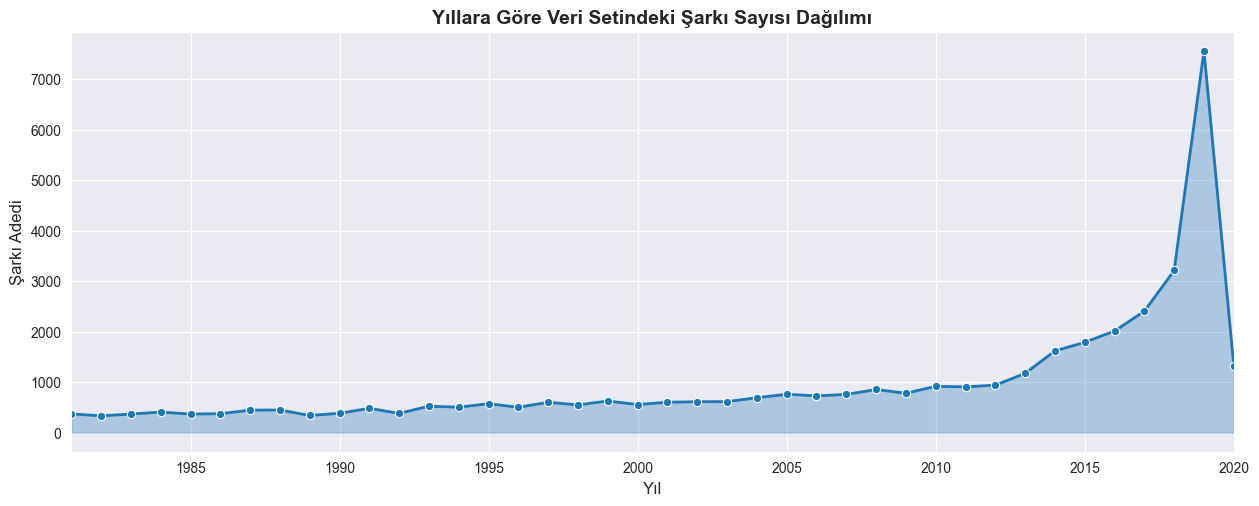

In [18]:
# Veri analizi sürecinin bu bölümünü açıklar
sns.set_style("darkgrid")
plt.figure(figsize=(15, 12))

# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
plt.subplot(2, 1, 1) # 2 satır, 1 sütunluk alanın 1. grafiği

# Veri analizi sürecinin bu bölümünü açıklar
year_counts = df['release_year'].value_counts().sort_index()

# Veri analizi sürecinin bu bölümünü açıklar
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="#1f77b4", linewidth=2)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.3, color="#1f77b4") # Altını doldur

plt.title("Yıllara Göre Veri Setindeki Şarkı Sayısı Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("Yıl", fontsize=12)
plt.ylabel("Şarkı Adedi", fontsize=12)

# Veri analizi sürecinin bu bölümünü açıklar
plt.xlim(df['release_year'].min(), df['release_year'].max())

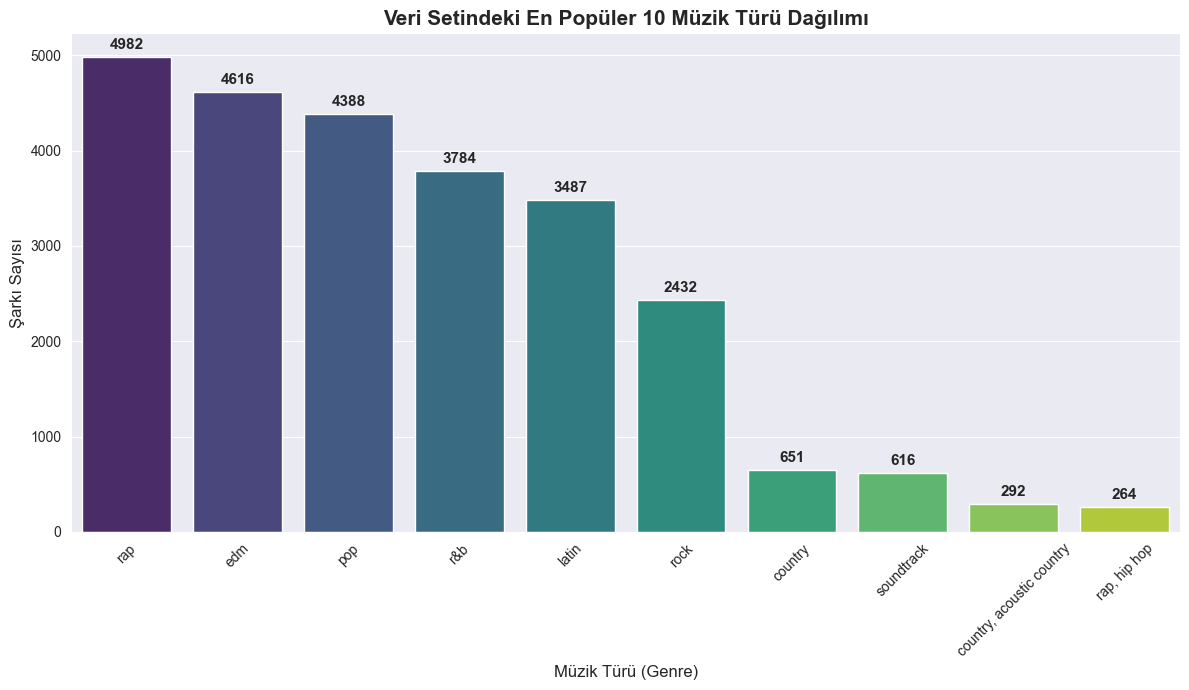

In [ ]:
top_10_genres = df['genre'].value_counts().head(10)

# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
plt.figure(figsize=(12, 7))  # Grafik boyutu

# Veri analizi sürecinin bu bölümünü açıklar
ax = sns.barplot(
    x=top_10_genres.index, 
    y=top_10_genres.values, 
    palette="viridis"  # Renk paleti (viridis, magma, coolwarm vb. olabilir)
)

plt.title("Veri Setindeki En Popüler 10 Müzik Türü Dağılımı", fontsize=15, fontweight='bold')
plt.xlabel("Müzik Türü (Genre)", fontsize=12)
plt.ylabel("Şarkı Sayısı", fontsize=12)

# Veri analizi sürecinin bu bölümünü açıklar
plt.xticks(rotation=45)

# Veri analizi sürecinin bu bölümünü açıklar
for i, v in enumerate(top_10_genres.values):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()  # Düzeni sıkıştırarak taşmaları önle
plt.show()

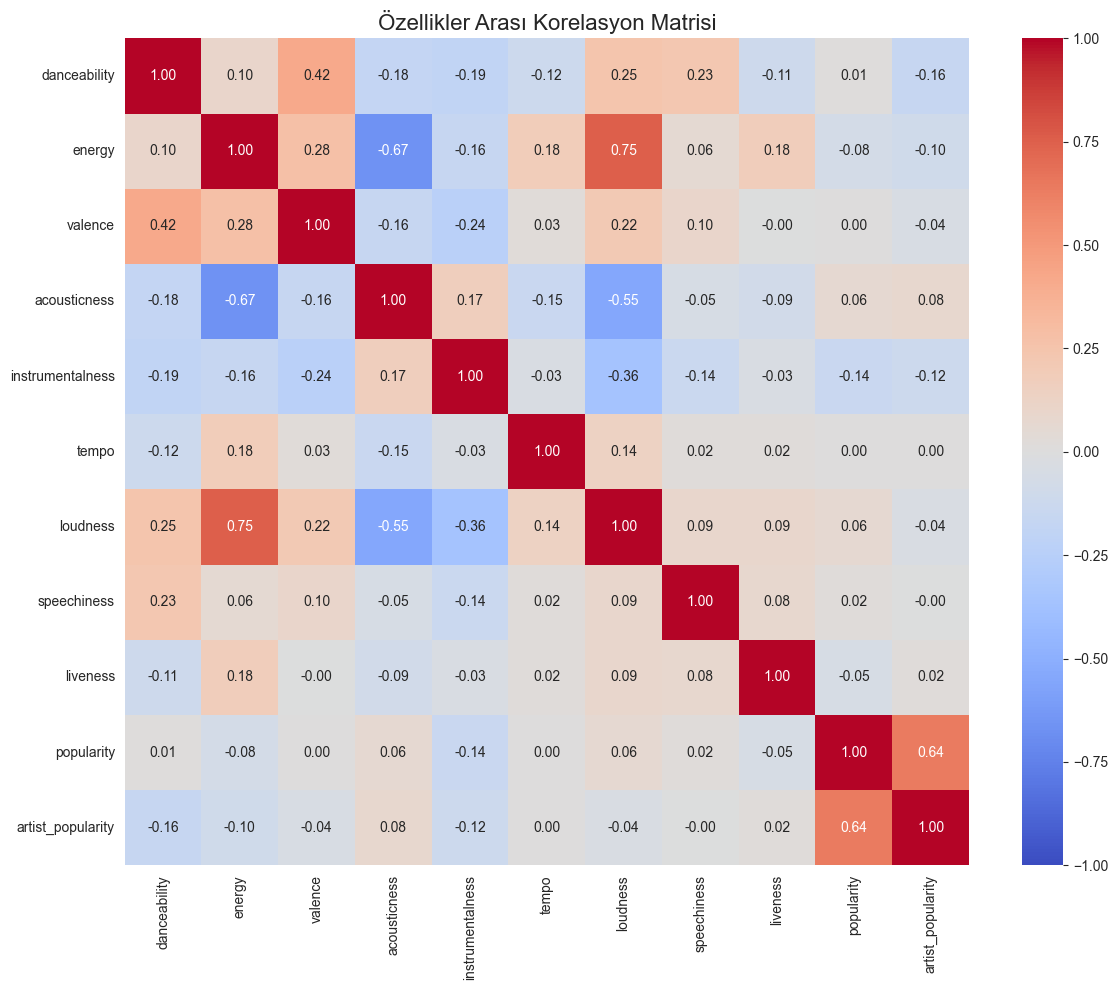

                   danceability    energy   valence  acousticness  \
danceability           1.000000  0.098673  0.416488     -0.177897   
energy                 0.098673  1.000000  0.279668     -0.667108   
valence                0.416488  0.279668  1.000000     -0.159419   
acousticness          -0.177897 -0.667108 -0.159419      1.000000   
instrumentalness      -0.189401 -0.164052 -0.237084      0.169303   
tempo                 -0.121698  0.180214  0.027658     -0.146763   
loudness               0.245342  0.753115  0.215493     -0.549729   
speechiness            0.233230  0.062368  0.101037     -0.051733   
liveness              -0.110047  0.175011 -0.003983     -0.087520   
popularity             0.008352 -0.075303  0.002306      0.064334   
artist_popularity     -0.162939 -0.095618 -0.040265      0.078620   

                   instrumentalness     tempo  loudness  speechiness  \
danceability              -0.189401 -0.121698  0.245342     0.233230   
energy                    -

In [20]:
# Veri analizi sürecinin bu bölümünü açıklar
numerical_cols = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'tempo', 'loudness', 'speechiness', 
                  'liveness', 'popularity', 'artist_popularity']

# Veri analizi sürecinin bu bölümünü açıklar
corr_matrix = df[numerical_cols].corr()

# Veri analizi sürecinin bu bölümünü açıklar
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Özellikler Arası Korelasyon Matrisi', fontsize=16)

# Veri analizi sürecinin bu bölümünü açıklar
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

# Veri analizi sürecinin bu bölümünü açıklar
print(corr_matrix)

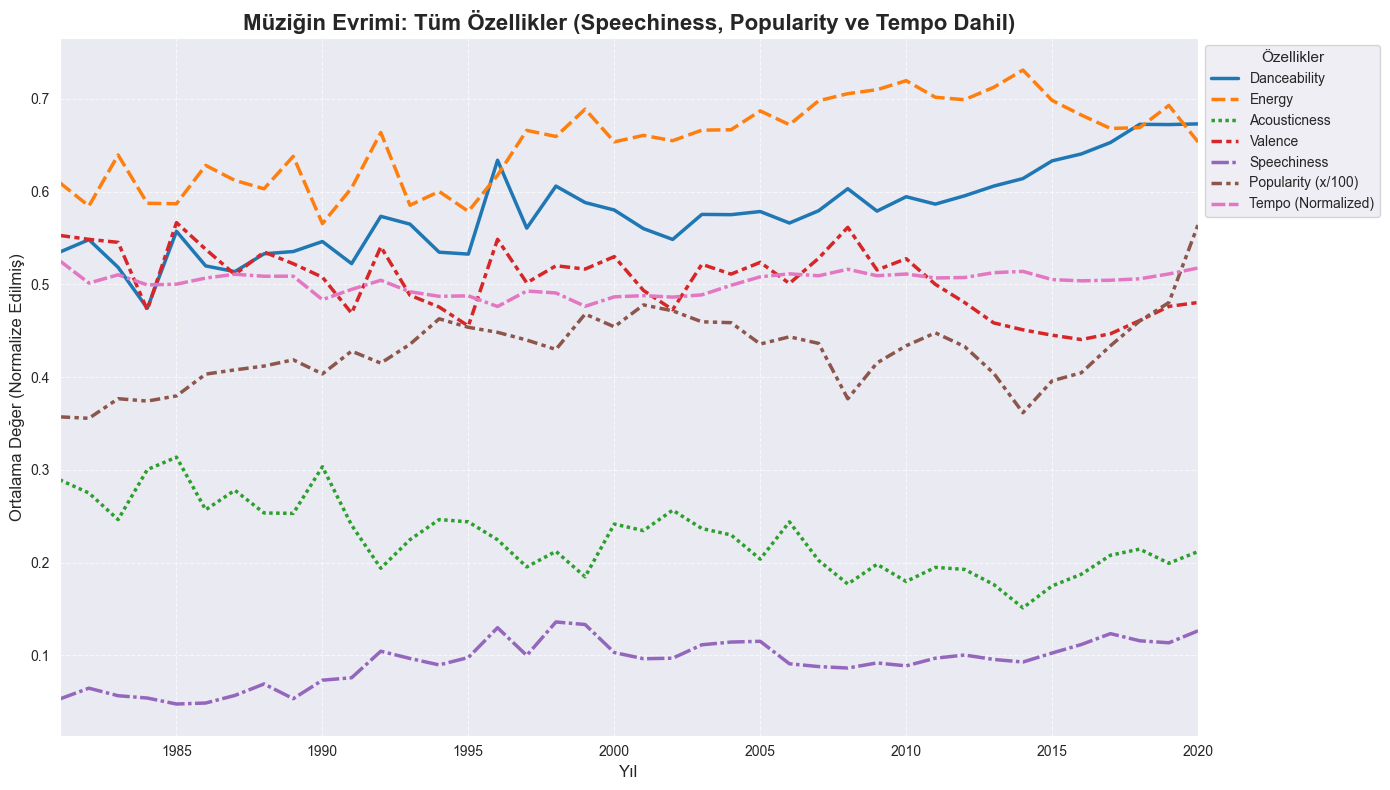

In [21]:
# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
df['popularity_scaled'] = df['popularity'] / 100
# Veri analizi sürecinin bu bölümünü açıklar
df['tempo_scaled'] = (df['tempo'] - df['tempo'].min()) / (df['tempo'].max() - df['tempo'].min())

# Veri analizi sürecinin bu bölümünü açıklar
features = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'popularity_scaled', 'tempo_scaled']
yearly_means = df.groupby('release_year')[features].mean()

# Veri analizi sürecinin bu bölümünü açıklar
yearly_means.columns = ['Danceability', 'Energy', 'Acousticness', 'Valence', 'Speechiness', 'Popularity (x/100)', 'Tempo (Normalized)']

# Veri analizi sürecinin bu bölümünü açıklar
plt.figure(figsize=(14, 8))
sns.lineplot(data=yearly_means, linewidth=2.5, palette="tab10")

# Veri analizi sürecinin bu bölümünü açıklar
plt.title('Müziğin Evrimi: Tüm Özellikler (Speechiness, Popularity ve Tempo Dahil)', fontsize=16, fontweight='bold')
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Ortalama Değer (Normalize Edilmiş)', fontsize=12)
plt.legend(title='Özellikler', title_fontsize='11', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(df['release_year'].min(), df['release_year'].max())

plt.tight_layout()
plt.show()

     genre  popularity  count
0  Country   56.260894   1767
1    Metal   54.011264    799
2      Pop   50.518985   6347
3      Rap   49.100110   6373
4     Rock   44.140879   3684
5    Latin   42.825678   3723
6      R&b   40.180011   3522
7      Edm   31.885641   4687


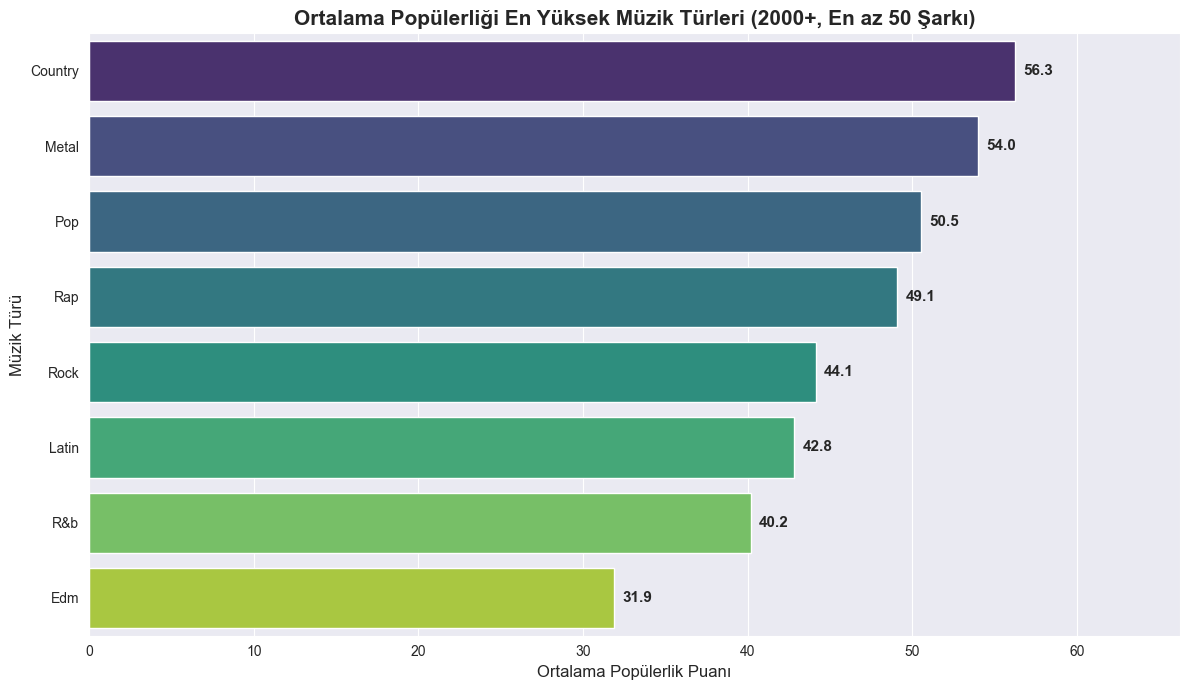

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV dosyasını oku
df = pd.read_csv("Genel_Veriseti.csv")

# 2000 yılı ve sonrasındaki şarkıları filtrele
df = df[df['release_year'] >= 2000].copy()

# Analiz edilecek ana müzik türleri
target_genres = ['rap', 'edm', 'pop', 'rock', 'latin', 'r&b', 'metal', 'country']

# Tür bazlı sonuçları tutacak liste
genre_data = []

# Her müzik türü için analiz yap
for target in target_genres:

    # İlgili türü içeren satırları bul
    mask = df['genre'].str.contains(target, case=False, na=False)
    subset = df[mask]

    # Türdeki toplam şarkı sayısı
    count = len(subset)

    # En az 50 şarkı varsa analize dahil et
    if count > 50:

        # Ortalama popülerlik hesapla
        avg_popularity = subset['popularity'].mean()

        # Sonuçları listeye ekle
        genre_data.append({
            'genre': target.capitalize(),
            'popularity': avg_popularity,
            'count': count
        })

# Listeyi DataFrame'e dönüştür
top_genres_df = pd.DataFrame(genre_data)

# Popülerliğe göre sırala
top_genres_df = top_genres_df.sort_values(
    by='popularity',
    ascending=False
).reset_index(drop=True)

# Sonuçları yazdır
print(top_genres_df)

# Grafik boyutu
plt.figure(figsize=(12, 7))

# FutureWarning hatası düzeltilmiş barplot
ax = sns.barplot(
    x='popularity',
    y='genre',
    hue='genre',          # palette uyarısını kaldırır
    data=top_genres_df,
    palette="viridis",
    legend=False
)

# Grafik başlığı
plt.title(
    'Ortalama Popülerliği En Yüksek Müzik Türleri (2000+, En az 50 Şarkı)',
    fontsize=15,
    fontweight='bold'
)

# Eksen isimleri
plt.xlabel('Ortalama Popülerlik Puanı', fontsize=12)
plt.ylabel('Müzik Türü', fontsize=12)

# Çubukların üzerine değer yaz
for i, v in enumerate(top_genres_df['popularity']):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# X ekseni sınırı
plt.xlim(0, top_genres_df['popularity'].max() + 10)

# Düzeni optimize et
plt.tight_layout()

# Grafiği kaydet
plt.savefig('broad_genres_avg_popularity_2000plus.png')

# Grafiği göster
plt.show()

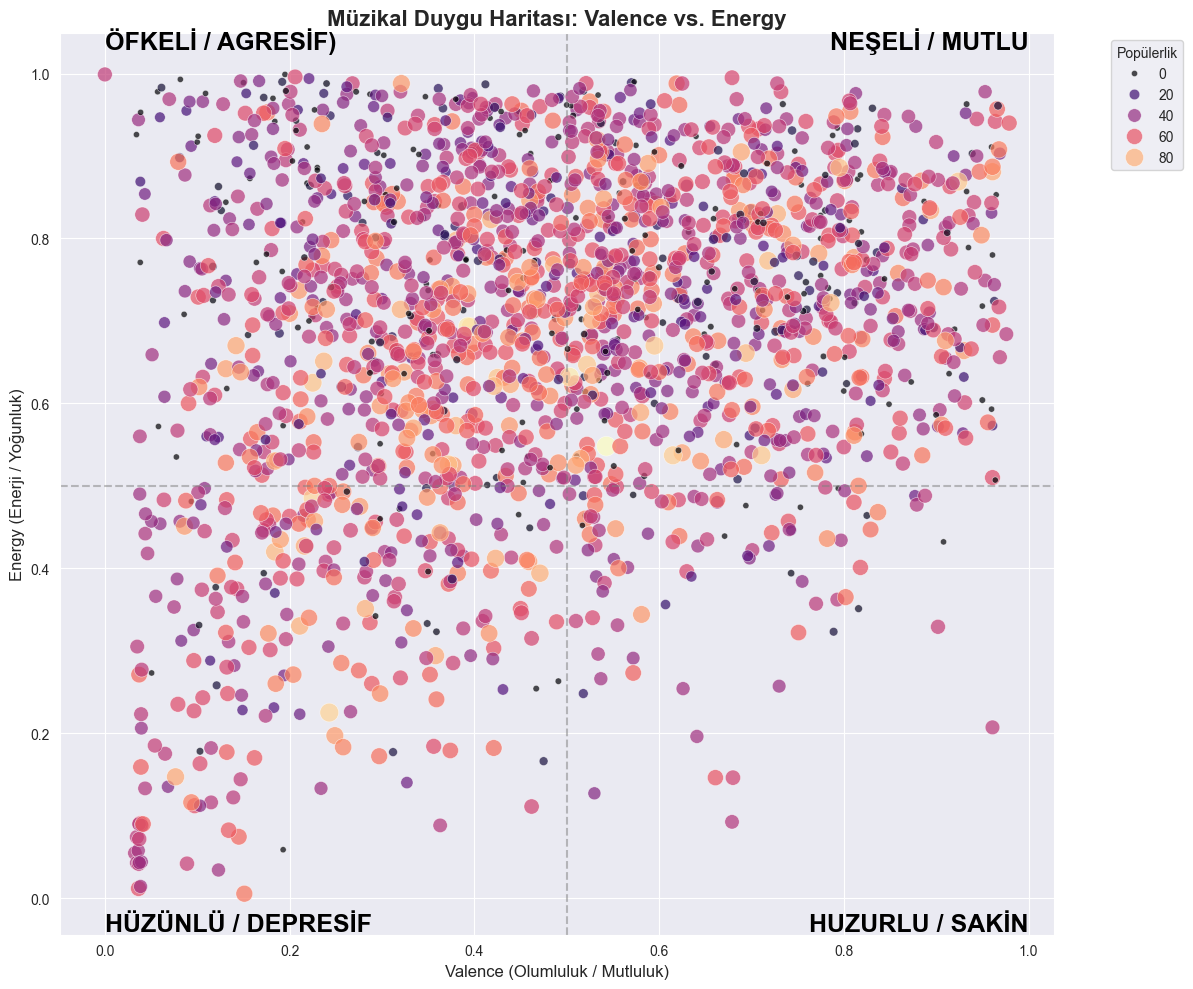

In [23]:
sample_df = df.sample(n=2000, random_state=42)

# Veri analizi sürecinin bu bölümünü açıklar
plt.figure(figsize=(12, 10))

# Veri analizi sürecinin bu bölümünü açıklar
sns.scatterplot(
    data=sample_df, 
    x='valence', 
    y='energy', 
    hue='popularity', 
    palette='magma', # Renk paleti (Koyu mor -> Parlak sarı)
    size='popularity', # Popüler şarkılar biraz daha büyük görünsün
    sizes=(20, 200),
    alpha=0.7 # Şeffaflık
)

# Veri analizi sürecinin bu bölümünü açıklar
plt.axhline(0.5, ls='--', color='gray', alpha=0.5) # Yatay orta çizgi
plt.axvline(0.5, ls='--', color='gray', alpha=0.5) # Dikey orta çizgi

# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar
plt.text(0.00, 1.03, 'ÖFKELİ / AGRESİF)', fontsize=18, fontweight='bold', color='black', ha='left')

# Veri analizi sürecinin bu bölümünü açıklar
plt.text(1.00, 1.03, 'NEŞELİ / MUTLU', fontsize=18, fontweight='bold', color='black', ha='right')

# Veri analizi sürecinin bu bölümünü açıklar
plt.text(0.0, -0.04, 'HÜZÜNLÜ / DEPRESİF', fontsize=18, fontweight='bold', color='black', ha='left')

# Veri analizi sürecinin bu bölümünü açıklar
plt.text(1.0, -0.04, 'HUZURLU / SAKİN', fontsize=18, fontweight='bold', color='black', ha='right')

# Veri analizi sürecinin bu bölümünü açıklar
plt.title('Müzikal Duygu Haritası: Valence vs. Energy', fontsize=16, fontweight='bold')
plt.xlabel('Valence (Olumluluk / Mutluluk)', fontsize=12)
plt.ylabel('Energy (Enerji / Yoğunluk)', fontsize=12)
plt.legend(title='Popülerlik', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('mood_map.png')
plt.show()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri analizi sürecinin bu bölümünü açıklar
df = pd.read_csv("Genel_Veriseti.csv")
# Veri analizi sürecinin bu bölümünü açıklar
df_filtered = df[df['release_year'] >= 2000].copy()

# Veri analizi sürecinin bu bölümünü açıklar
genre_popularity = df_filtered.groupby(['release_year', 'genre'])['popularity'].mean().reset_index()

# Veri analizi sürecinin bu bölümünü açıklar
top_genres = genre_popularity.loc[genre_popularity.groupby('release_year')['popularity'].idxmax()]

print(top_genres)

      release_year                                              genre  \
36            2000                                   glam metal, rock   
125           2001                                    new age, celtic   
180           2002                                          dancehall   
270           2003                                       finnish rock   
389           2004                                   reggaeton, latin   
403           2005                                            britpop   
558           2006                                          soft rock   
590           2007  east coast hip hop, old school hip hop, hardco...   
718           2008                                           pop, r&b   
804           2009       nu metal, rap metal, rock, alternative metal   
905           2010                               reggae, roots reggae   
982           2011  old school hip hop, g-funk, gangster rap, west...   
1054          2012                                 

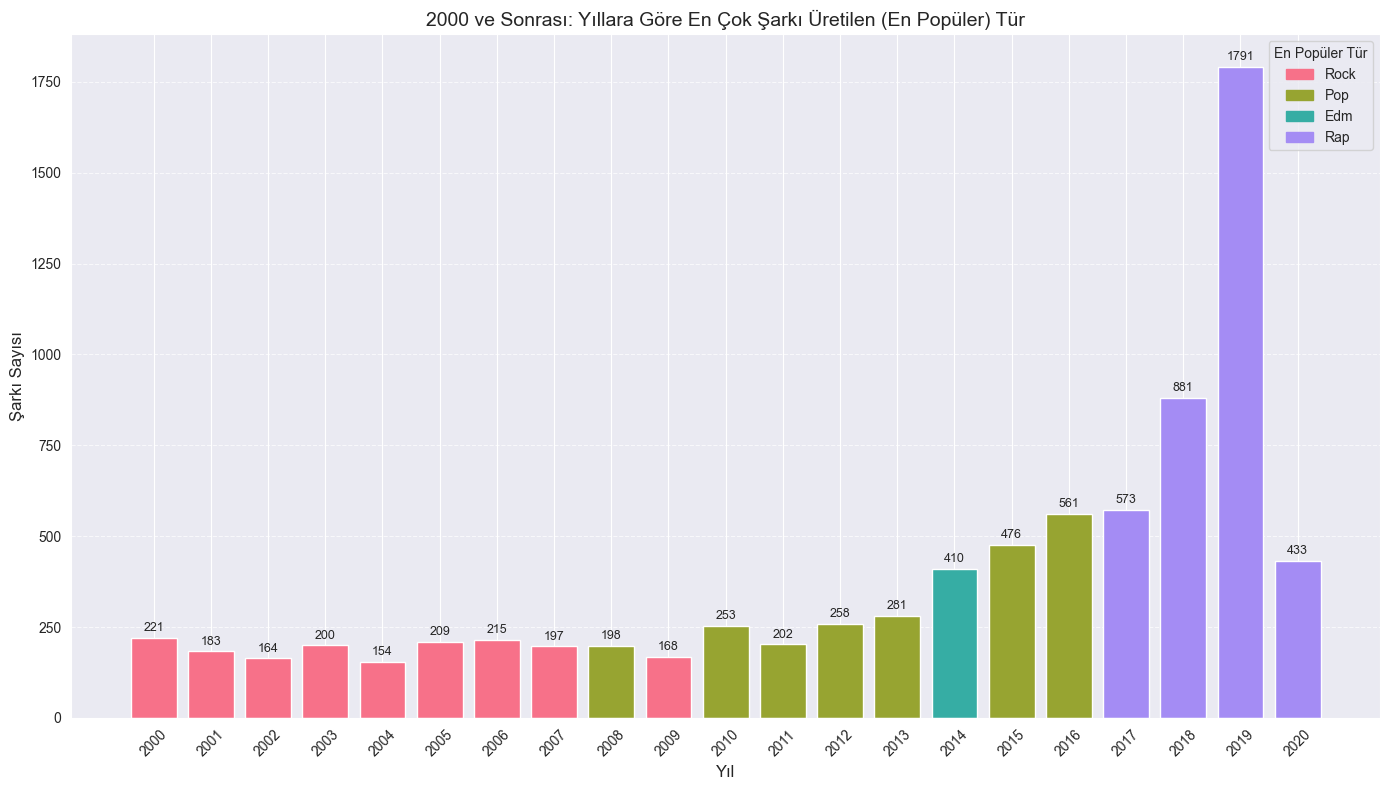

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veri analizi sürecinin bu bölümünü açıklar
df = pd.read_csv("Genel_Veriseti.csv")
df_filtered = df[df['release_year'] >= 2000].copy()

target_genres = ['rap', 'edm', 'pop', 'rock', 'latin', 'r&b', 'metal', 'country']

# Veri analizi sürecinin bu bölümünü açıklar
genre_stats = []

for target in target_genres:
# Veri analizi sürecinin bu bölümünü açıklar
    mask = df_filtered['genre'].str.contains(target, case=False, na=False)
    subset = df_filtered[mask]
    
# Veri analizi sürecinin bu bölümünü açıklar
    yearly_counts = subset.groupby('release_year').size()
    
    for year in yearly_counts.index:
        genre_stats.append({
            'Yıl': year,
            'Tür': target.capitalize(),
            'Şarkı Sayısı': yearly_counts[year]
        })

stats_df = pd.DataFrame(genre_stats)

# Veri analizi sürecinin bu bölümünü açıklar
top_genres_per_year = stats_df.loc[stats_df.groupby('Yıl')['Şarkı Sayısı'].idxmax()].sort_values('Yıl')

# Veri analizi sürecinin bu bölümünü açıklar
plt.figure(figsize=(14, 8))

# Veri analizi sürecinin bu bölümünü açıklar
unique_genres = top_genres_per_year['Tür'].unique()
palette = sns.color_palette("husl", len(unique_genres))
genre_color_map = dict(zip(unique_genres, palette))

# Veri analizi sürecinin bu bölümünü açıklar
colors = top_genres_per_year['Tür'].map(genre_color_map)

# Veri analizi sürecinin bu bölümünü açıklar
bars = plt.bar(top_genres_per_year['Yıl'], top_genres_per_year['Şarkı Sayısı'], color=colors)

# Veri analizi sürecinin bu bölümünü açıklar
handles = [plt.Rectangle((0,0),1,1, color=genre_color_map[g]) for g in unique_genres]
plt.legend(handles, unique_genres, title="En Popüler Tür")

# Veri analizi sürecinin bu bölümünü açıklar
for bar, genre in zip(bars, top_genres_per_year['Tür']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}',
             ha='center', va='bottom', rotation=0, fontsize=9)
# Veri analizi sürecinin bu bölümünü açıklar
# Veri analizi sürecinin bu bölümünü açıklar

plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Şarkı Sayısı', fontsize=12)
plt.title('2000 ve Sonrası: Yıllara Göre En Çok Şarkı Üretilen (En Popüler) Tür', fontsize=14)
plt.xticks(top_genres_per_year['Yıl'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('top_genre_volume_per_year_bar.png')